### Boosting

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
import pickle
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


### Leemos el Dataset

In [22]:
df= pd.read_csv("../data/raw/diabetes.csv")
df.head

<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50 

### Definimos get-metrics

In [23]:
def get_classifier_metrics(y_predict_test, y_test, y_predict_train, y_train, average='micro'):
    metrics_train = (accuracy_score(y_train, y_predict_train),
                     f1_score(y_train, y_predict_train, average=average),
                     precision_score(y_train, y_predict_train, average=average),
                     recall_score(y_train, y_predict_train, average=average))
    metrics_test = (accuracy_score(y_test, y_predict_test),
                    f1_score(y_test, y_predict_test, average=average),
                    precision_score(y_test, y_predict_test, average=average),
                    recall_score(y_test, y_predict_test, average=average))
    return pd.DataFrame(data=[metrics_train, metrics_test],
                        columns=['Accuracy', 'F1 Score', 'Precision', 'Recall'],
                        index=['Train set', 'Test set'])

In [24]:
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = df[['Glucose', 
                                                                          'BloodPressure', 
                                                                          'SkinThickness', 
                                                                          'Insulin', 
                                                                          'BMI']].replace(0, np.nan)
df.isnull().sum().sort_values(ascending=False)

Insulin                     374
SkinThickness               227
BloodPressure                35
BMI                          11
Glucose                       5
Pregnancies                   0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

### Construye un boosting
Una forma de optimizar y mejorar los resultados es generar un boosting de tal forma que haya una variedad necesaria que enriquezca la predicción. Entrénalo y analiza sus resultados. Prueba a modificar los hiperparámetros que definen al modelo con distintos valores y analiza su impacto con la precisión final y grafica las conclusiones.

/home/vscode/.local/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:27:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vscode/.local/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:27:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vscode/.local/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:27:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vscode/.local/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:27:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


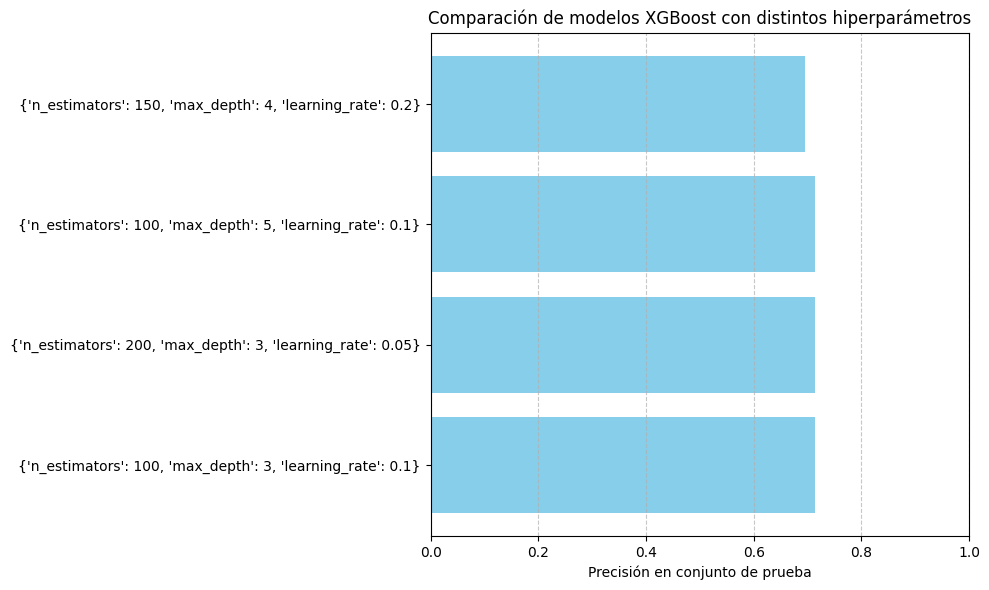

[{'params': {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1},
  'accuracy': 0.7142857142857143},
 {'params': {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05},
  'accuracy': 0.7142857142857143},
 {'params': {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1},
  'accuracy': 0.7142857142857143},
 {'params': {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.2},
  'accuracy': 0.6948051948051948}]

In [30]:
# Separar características y variable objetivo
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Probar distintos sets de hiperparámetros
param_sets = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.1},
    {"n_estimators": 150, "max_depth": 4, "learning_rate": 0.2},
]

# Entrenar modelos y guardar resultados
results = []

for params in param_sets:
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", **params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append({
        "params": params,
        "accuracy": accuracy
    })

# Preparar datos para graficar
labels = [str(r["params"]) for r in results]
accuracies = [r["accuracy"] for r in results]

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(labels, accuracies, color="skyblue")
plt.xlabel("Precisión en conjunto de prueba")
plt.title("Comparación de modelos XGBoost con distintos hiperparámetros")
plt.xlim(0, 1)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Mostrar resultados numéricos
results


In [31]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0])

### Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

In [27]:
with open("../models/xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("../models/xgboost_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)


### Analiza y compara los resultados de los modelos
Haz un estudio ahora de los tres modelos utilizados, analiza sus predicciones, la clase con más precisión de predicción y la que menos. ¿Con cuál de los tres modelos te quedas?


📊 Resultados para XGBoost:
----------------------------------------
📝 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.79      0.80        99
    Diabetes       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



/home/vscode/.local/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:31:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


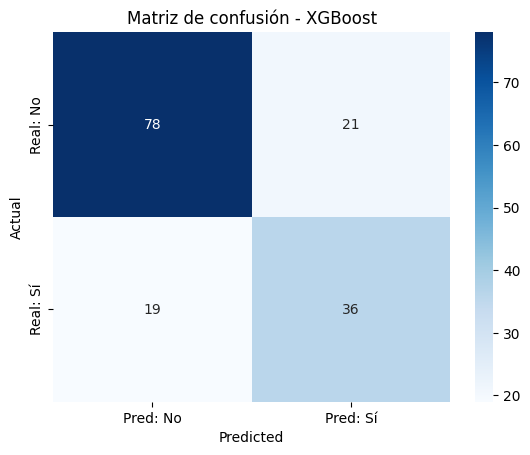


📊 Resultados para RandomForest:
----------------------------------------
📝 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.79      0.78      0.79        99
    Diabetes       0.61      0.64      0.62        55

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



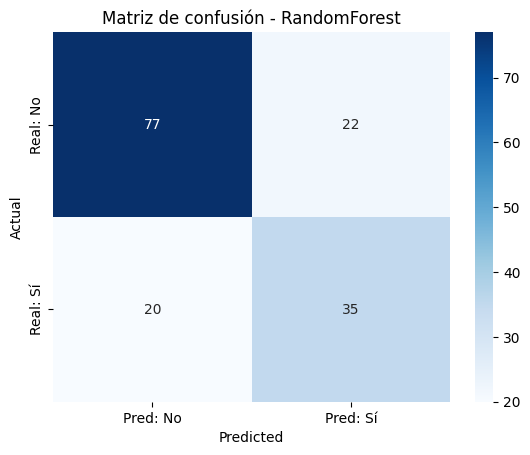


📊 Resultados para DecisionTree:
----------------------------------------
📝 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.84      0.82        99
    Diabetes       0.68      0.62      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



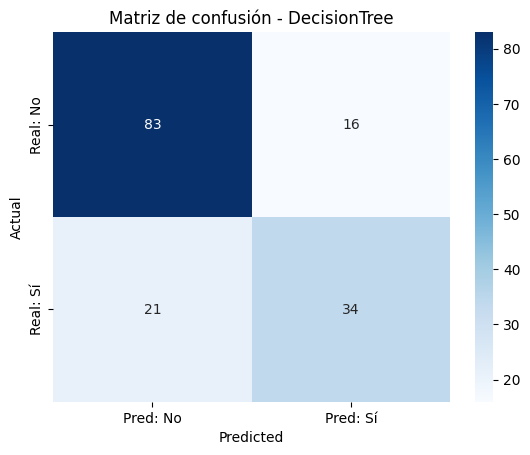

In [36]:
models = {
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", n_estimators=75, max_depth=2, learning_rate=0.1),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=3, random_state=42)
}

# 7. Entrenar, predecir y evaluar
for name, model in models.items():
    print(f"\n📊 Resultados para {name}:\n{'-'*40}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Clasification report
    print("📝 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Pred: No", "Pred: Sí"],
                yticklabels=["Real: No", "Real: Sí"])
    plt.title(f"Matriz de confusión - {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()